Transfer learning od modelot so novi podatoci na stari podatoci


In [36]:
import pandas as pd
import glob
import os, random
import tensorflow as tf
import numpy as np
from sklearn.model_selection import GroupShuffleSplit

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [37]:
#vcituvanje na modelot novi_model_version2.ipynb za da go iskoristime za transfer learning
MODEL_PATH = r"D:\EMTEQ\novi\chewing_model_right.keras"
model = tf.keras.models.load_model(MODEL_PATH)
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 200, 64)        │         5,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 200, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 100, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 50, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 488,389 (1.86 MB)

 Trainable params: 162,497 (634.75 KB)

 Non-trainable params: 896 (3.50 KB)

 Optimizer params: 324,996 (1.24 MB)

In [38]:
DATA_DIR = r"D:\EMTEQ\modeli\za_transfer_stari"
OUT_PATH = os.path.join(DATA_DIR, "old_merged_filtered.csv")

label_col   = "Annotations"
subject_col = "subject"

# za da bidat isti i da moze da se upotrebi TL, inaku znaeme deka se od senzori od leva str
RENAME_MAP = {
    "Accelerometer/Raw.X": "Accelerometer X",
    "Accelerometer/Raw.Y": "Accelerometer Y",

    "Gyroscope/Raw.X": "Gyroscope X",
    "Gyroscope/Raw.Y": "Gyroscope Y",

    "RotationVector/Raw.X": "Rotation Vector X",
    "RotationVector/Raw.Y": "Rotation Vector Y",

    # LeftTemple -> именуваме како RightTemple за да одговараат на моделот
    "Nav/Raw.X[LeftTemple]": "Navigation Right Temple X",
    "Nav/Raw.Y[LeftTemple]": "Navigation Right Temple Y",
    "Prox/Raw[LeftTemple]": "Proximity Right Temple",
    "Nav/IQ[LeftTemple]": "Navigation Right Temple IQ",
    "Nav/Shutter[LeftTemple]": "Navigation Right Temple Shutter",
    "Nav/FrameAvg[LeftTemple]": "Navigation Right Temple Frame Avg",
}

FEATURE_COLS = [
    "Accelerometer X",
    "Accelerometer Y",
    "Gyroscope X",
    "Gyroscope Y",
    "Rotation Vector X",
    "Rotation Vector Y",
    "Navigation Right Temple X",
    "Navigation Right Temple Y",
    "Proximity Right Temple",
    "Navigation Right Temple IQ",
    "Navigation Right Temple Shutter",
    "Navigation Right Temple Frame Avg",
]

csv_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.csv")))
print(f"Found {len(csv_files)} files")

dfs = []
for fpath in csv_files:
    df = pd.read_csv(fpath)

    # subject od filename
    df[subject_col] = os.path.basename(fpath).replace("_eating_processed.csv", "")

    df = df.rename(columns=RENAME_MAP)

    dfs.append(df)

old_raw = pd.concat(dfs, ignore_index=True)
print("Merged shape:", old_raw.shape)


Found 25 files
Merged shape: (803306, 24)


In [39]:
#proverka dali se napraveni site transformacii 
needed = set(FEATURE_COLS + [label_col, subject_col])
missing = [c for c in needed if c not in old_raw.columns]
if missing:
    raise ValueError(f"Missing required columns in old data: {missing}")

In [40]:
#isti features kako i od novi_model_version2.ipynb
keep_cols = FEATURE_COLS + [label_col, subject_col]
old_clean = old_raw[keep_cols].copy()

old_clean = old_clean.dropna(subset=FEATURE_COLS + [label_col])
old_clean = old_clean.sort_values(["subject"]).reset_index(drop=True)
old_clean = old_clean[old_clean[label_col].isin([0, 1])]

print("After filtering:", old_clean.shape)
print("Label dist:\n", old_clean[label_col].value_counts())

old_clean.to_csv(OUT_PATH, index=False)
print("Saved:", OUT_PATH)

print("Total columns:", old_clean.shape[1])   # треба 14 (12+label+subject)
print("Features only:", len(FEATURE_COLS)) # 12


After filtering: (803306, 14)
Label dist:
 Annotations
1    522982
0    280324
Name: count, dtype: int64
Saved: D:\EMTEQ\modeli\za_transfer_stari\old_merged_filtered.csv
Total columns: 14
Features only: 12


In [41]:
print(old_clean.columns.tolist())


['Accelerometer X', 'Accelerometer Y', 'Gyroscope X', 'Gyroscope Y', 'Rotation Vector X', 'Rotation Vector Y', 'Navigation Right Temple X', 'Navigation Right Temple Y', 'Proximity Right Temple', 'Navigation Right Temple IQ', 'Navigation Right Temple Shutter', 'Navigation Right Temple Frame Avg', 'Annotations', 'subject']


In [42]:
model = tf.keras.models.load_model(MODEL_PATH)

### F1 freeze backbone: Train samo na Dense i Dense_1
### DENSE FINETUNING

In [43]:
# raw arrays
X_all = old_clean[FEATURE_COLS].values.astype(np.float32)
y_all = old_clean[label_col].values.astype(np.int32)
groups = old_clean[subject_col].values

# split po subject
gss = GroupShuffleSplit(test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(X_all, y_all, groups))

X_train_raw, X_val_raw = X_all[train_idx], X_all[val_idx]
y_train_raw, y_val_raw = y_all[train_idx], y_all[val_idx]
g_train, g_val = groups[train_idx], groups[val_idx]

print("Train subjects:", sorted(set(g_train)))
print("Val subjects:", sorted(set(g_val)))

print("Raw train:", X_train_raw.shape, "Raw val:", X_val_raw.shape)

def make_windows_by_subject(X, y, subj, win=200, step=25):
    Xw, yw = [], []
    for s in np.unique(subj):
        idx = np.where(subj == s)[0]
        Xs, ys = X[idx], y[idx]
        for i in range(0, len(Xs) - win + 1, step):
            y_win = ys[i:i+win]
            label = int(y_win[-1])
      
            Xw.append(Xs[i:i+win])
            yw.append(label)
    return np.array(Xw, dtype=np.float32), np.array(yw, dtype=np.int32)

# windowing
X_train, y_train = make_windows_by_subject(X_train_raw, y_train_raw, g_train, win=200, step=25)
X_val, y_val     = make_windows_by_subject(X_val_raw,   y_val_raw,   g_val,   win=200, step=25)

print("Windows train:", X_train.shape, "labels:", np.bincount(y_train))
print("Windows val:",   X_val.shape,   "labels:", np.bincount(y_val))

# normalization (fit на train)
mu = X_train.mean(axis=(0,1), keepdims=True)
sigma = X_train.std(axis=(0,1), keepdims=True) + 1e-8

X_train_z = (X_train - mu) / sigma
X_val_z   = (X_val   - mu) / sigma


Train subjects: ['BojanRadovski', 'DamjanSrebrenikovski', 'DanielaKovachovska', 'FilipSivevski', 'GoricaKovachovska', 'IlinaKovachovska', 'IvaJovanova', 'JovanaKostadinovska', 'KristijanMilosheski', 'MarkoKostov', 'MatejZlatkov', 'NikolaDimovski', 'OgnenSekuloski', 'SashkoKovachovski', 'StefanDinushev', 'StefanijaLazarovska', 'Tarekeating_processed.csv', 'TomiJovanoveating_processed.csv', 'VaskoDimitrovskieating_processed.csv', 'VladimirPetroveating_processed.csv']
Val subjects: ['AndrejPetrov', 'IvanaKiprijanovska', 'MarijaKovachovska', 'SaraKovachovska', 'VedranaPetreskaeating_processed.csv']
Raw train: (625984, 12) Raw val: (177322, 12)
Windows train: (24891, 200, 12) labels: [ 8779 16112]
Windows val: (7056, 200, 12) labels: [2382 4674]


In [44]:
#freeze
for layer in model.layers:
    layer.trainable = False

# Unfreeze samo dense и dense_1
for layer in model.layers:
    if isinstance(layer, tf.keras.layers.Dense):
        layer.trainable = True

# sanity check
print("\nTrainable layers (Phase 1):")
for l in model.layers:
    if l.trainable:
        print(" -", l.name)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ],
)


Trainable layers (Phase 1):
 - dense
 - dense_1


In [45]:
cb = [
    tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max", factor=0.5, patience=2, min_lr=1e-6),
]

hist1 = model.fit(
    X_train_z, y_train,
    validation_data=(X_val_z, y_val),
    epochs=40,
    batch_size=256,
    callbacks=cb,
    verbose=1
)


Epoch 1/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 23s 158ms/step - accuracy: 0.7566 - auc: 0.7965 - loss: 0.6209 - precision: 0.7993 - recall: 0.8332 - val_accuracy: 0.8179 - val_auc: 0.8433 - val_loss: 0.4661 - val_precision: 0.8156 - val_recall: 0.9369 - learning_rate: 1.0000e-04
Epoch 2/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step - accuracy: 0.7683 - auc: 0.7964 - loss: 0.5332 - precision: 0.7903 - recall: 0.8738 - val_accuracy: 0.8152 - val_auc: 0.8461 - val_loss: 0.4451 - val_precision: 0.8025 - val_recall: 0.9564 - learning_rate: 1.0000e-04
Epoch 3/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step - accuracy: 0.7746 - auc: 0.8017 - loss: 0.5115 - precision: 0.7840 - recall: 0.8998 - val_accuracy: 0.8135 - val_auc: 0.8498 - val_loss: 0.4378 - val_precision: 0.7990 - val_recall: 0.9600 - learning_rate: 1.0000e-04
Epoch 4/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 11s 111ms/step - accuracy: 0.7780 - auc: 0.8105 - loss: 0.4981 - precision: 0.7821 - recall: 0.9107 - val_accuracy: 0.8169 - val_auc: 0.8528 - val_lo

In [46]:
from sklearn.metrics import confusion_matrix, classification_report

# default threshold 0.5 
y_prob = model.predict(X_val_z, batch_size=256).ravel()
y_pred = (y_prob >= 0.64).astype(int)

cm = confusion_matrix(y_val, y_pred)
print("Confusion matrix:\n", cm)
print(classification_report(y_val, y_pred, digits=4))

28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step
Confusion matrix:
 [[1820  562]
 [ 920 3754]]
              precision    recall  f1-score   support

           0     0.6642    0.7641    0.7107      2382
           1     0.8698    0.8032    0.8352      4674

    accuracy                         0.7900      7056
   macro avg     0.7670    0.7836    0.7729      7056
weighted avg     0.8004    0.7900    0.7931      7056



In [47]:
model.save(r"D:\EMTEQ\modeli\phase1_dense_only.keras")

 The model is initially trained on newly recorded data and learns general chewing patterns. In Phase 1 of transfer learning, the backbone layers are frozen, and only the classification layers are fine-tuned on the old data, allowing the model to learn how to interpret the already extracted features in the new domain. This phase is crucial for successful adaptation. Then, by partially unfreezing the last convolutional block, the model further adjusts, after which a final evaluation is performed on a separate test set.

### F2: Partial unfreeze
### UNFREEZE conv1d_2

In [48]:
# se freeze 
for layer in model.layers:
    layer.trainable = False

# F1 ni ostanuva za train dense i dense_1
for layer in model.layers:
    if isinstance(layer, tf.keras.layers.Dense):
        layer.trainable = True

# unfreeze conv1d_2 (posledniot conv sloj)
for layer in model.layers:
    if layer.name == "conv1d_2":
        layer.trainable = True

print("\nTrainable layers (Phase 2):")
for l in model.layers:
    if l.trainable:
        print(" -", l.name)



Trainable layers (Phase 2):
 - conv1d_2
 - dense
 - dense_1


In [49]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # мал LR
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ],
)


In [50]:
cb2 = [
    tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=7, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max", factor=0.5, patience=3, min_lr=1e-6),
]

hist2 = model.fit(
    X_train_z, y_train,
    validation_data=(X_val_z, y_val),
    epochs=40,
    batch_size=256,
    callbacks=cb2,
    verbose=1
)


Epoch 1/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 27s 185ms/step - accuracy: 0.8110 - auc: 0.8500 - loss: 0.4458 - precision: 0.8202 - recall: 0.9068 - val_accuracy: 0.8211 - val_auc: 0.8623 - val_loss: 0.4175 - val_precision: 0.8463 - val_recall: 0.8920 - learning_rate: 1.0000e-05
Epoch 2/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 15s 149ms/step - accuracy: 0.8105 - auc: 0.8519 - loss: 0.4439 - precision: 0.8199 - recall: 0.9065 - val_accuracy: 0.8204 - val_auc: 0.8627 - val_loss: 0.4172 - val_precision: 0.8466 - val_recall: 0.8902 - learning_rate: 1.0000e-05
Epoch 3/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 14s 147ms/step - accuracy: 0.8143 - auc: 0.8520 - loss: 0.4432 - precision: 0.8225 - recall: 0.9094 - val_accuracy: 0.8207 - val_auc: 0.8631 - val_loss: 0.4166 - val_precision: 0.8467 - val_recall: 0.8907 - learning_rate: 1.0000e-05
Epoch 4/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 15s 147ms/step - accuracy: 0.8135 - auc: 0.8513 - loss: 0.4435 - precision: 0.8226 - recall: 0.9077 - val_accuracy: 0.8213 - val_auc: 0.8632 - val_lo

In [51]:
y_prob = model.predict(X_val_z, batch_size=256).ravel()
y_pred = (y_prob >= 0.5).astype(int)

cm = confusion_matrix(y_val, y_pred)
print("Confusion Matrix (Phase 2):\n", cm)
print(classification_report(y_val, y_pred, digits=4))


28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 204ms/step
Confusion Matrix (Phase 2):
 [[1627  755]
 [ 525 4149]]
              precision    recall  f1-score   support

           0     0.7560    0.6830    0.7177      2382
           1     0.8460    0.8877    0.8664      4674

    accuracy                         0.8186      7056
   macro avg     0.8010    0.7854    0.7920      7056
weighted avg     0.8157    0.8186    0.8162      7056



In [52]:
model.save(r"D:\EMTEQ\modeli\phase2_unfreeze_conv1d2.keras")

cisto za proba i sporedba

### UNFREEZE conv1d_1 i conv1d_2

In [53]:
# se freeze 
for layer in model.layers:
    layer.trainable = False

# F1 ni ostanuva za train dense i dense_1
for layer in model.layers:
    if isinstance(layer, tf.keras.layers.Dense):
        layer.trainable = True

# unfreeze conv1d_2 (posledniot conv sloj)
for layer in model.layers:
    if layer.name in ["conv1d_1", "conv1d_2"]:
        layer.trainable = True
    if "batch_normalization" in layer.name:
        layer.trainable = False # BatchNorm sloevite ne gi trenirame frozen


print("\nTrainable layers (Phase 2):")
for l in model.layers:
    if l.trainable:
        print(" -", l.name)



Trainable layers (Phase 2):
 - conv1d_1
 - conv1d_2
 - dense
 - dense_1


In [54]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ],
)


In [55]:
cb3 = [
    tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=7, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max", factor=0.5, patience=3, min_lr=1e-6),
]

hist3 = model.fit(
    X_train_z, y_train,
    validation_data=(X_val_z, y_val),
    epochs=40,
    batch_size=256,
    callbacks=cb2,
    verbose=1
)


Epoch 1/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 28s 229ms/step - accuracy: 0.8217 - auc: 0.8584 - loss: 0.4290 - precision: 0.8278 - recall: 0.9148 - val_accuracy: 0.8175 - val_auc: 0.8648 - val_loss: 0.4145 - val_precision: 0.8469 - val_recall: 0.8843 - learning_rate: 1.0000e-05
Epoch 2/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 20s 204ms/step - accuracy: 0.8230 - auc: 0.8615 - loss: 0.4251 - precision: 0.8280 - recall: 0.9171 - val_accuracy: 0.8132 - val_auc: 0.8638 - val_loss: 0.4174 - val_precision: 0.8470 - val_recall: 0.8763 - learning_rate: 1.0000e-05
Epoch 3/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 19s 197ms/step - accuracy: 0.8228 - auc: 0.8631 - loss: 0.4229 - precision: 0.8272 - recall: 0.9181 - val_accuracy: 0.8119 - val_auc: 0.8634 - val_loss: 0.4189 - val_precision: 0.8468 - val_recall: 0.8742 - learning_rate: 1.0000e-05
Epoch 4/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 20s 201ms/step - accuracy: 0.8252 - auc: 0.8643 - loss: 0.4213 - precision: 0.8283 - recall: 0.9209 - val_accuracy: 0.8101 - val_auc: 0.8631 - val_lo

In [56]:
y_prob = model.predict(X_val_z, batch_size=256).ravel()
y_pred = (y_prob >= 0.5).astype(int)

cm = confusion_matrix(y_val, y_pred)
print("Confusion Matrix (Phase 2):\n", cm)
print(classification_report(y_val, y_pred, digits=4))



28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step
Confusion Matrix (Phase 2):
 [[1635  747]
 [ 541 4133]]
              precision    recall  f1-score   support

           0     0.7514    0.6864    0.7174      2382
           1     0.8469    0.8843    0.8652      4674

    accuracy                         0.8175      7056
   macro avg     0.7992    0.7853    0.7913      7056
weighted avg     0.8147    0.8175    0.8153      7056



In [57]:
model.save(r"D:\EMTEQ\modeli\phase2b_unfreeze_conv1d1_conv1d2.keras")

In [58]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score

def eval_model(model_path, X_val_z, y_val, thr=0.5):
    m = tf.keras.models.load_model(model_path)

    y_prob = m.predict(X_val_z, batch_size=256).ravel()
    y_pred = (y_prob >= thr).astype(int)

    cm = confusion_matrix(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, zero_division=0)
    rec = recall_score(y_val, y_pred, zero_division=0)
    auc = roc_auc_score(y_val, y_prob)

    return {
        "model": model_path.split("\\")[-1],
        "threshold": thr,
        "f1": f1,
        "precision": prec,
        "recall": rec,
        "auc": auc,
        "tn": int(cm[0,0]),
        "fp": int(cm[0,1]),
        "fn": int(cm[1,0]),
        "tp": int(cm[1,1]),
    }

paths = [
    r"D:\EMTEQ\modeli\phase1_dense_only.keras",
    r"D:\EMTEQ\modeli\phase2_unfreeze_conv1d2.keras",
    r"D:\EMTEQ\modeli\phase2b_unfreeze_conv1d1_conv1d2.keras",
]

results = [eval_model(p, X_val_z, y_val, thr=0.5) for p in paths]
results


28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step


[{'model': 'phase1_dense_only.keras',
  'threshold': 0.5,
  'f1': 0.8686321491822064,
  'precision': 0.846497461928934,
  'recall': 0.8919554985023534,
  'auc': np.float64(0.8618286772818676),
  'tn': 1626,
  'fp': 756,
  'fn': 505,
  'tp': 4169},
 {'model': 'phase2_unfreeze_conv1d2.keras',
  'threshold': 0.5,
  'f1': 0.8663604092712466,
  'precision': 0.8460440456769984,
  'recall': 0.8876765083440308,
  'auc': np.float64(0.8651086974876112),
  'tn': 1627,
  'fp': 755,
  'fn': 525,
  'tp': 4149},
 {'model': 'phase2b_unfreeze_conv1d1_conv1d2.keras',
  'threshold': 0.5,
  'f1': 0.8651873560812225,
  'precision': 0.8469262295081967,
  'recall': 0.8842533162173727,
  'auc': np.float64(0.8647842253644596),
  'tn': 1635,
  'fp': 747,
  'fn': 541,
  'tp': 4133}]

In [59]:
df_cmp = pd.DataFrame(results).sort_values(by="f1", ascending=False)
df_cmp

,model,threshold,f1,precision,recall,auc,tn,fp,fn,tp
0,phase1_dense_only.keras,0.5,0.868632,0.846497,0.891955,0.861829,1626,756,505,4169
1,phase2_unfreeze_conv1d2.keras,0.5,0.866360,0.846044,0.887677,0.865109,1627,755,525,4149
2,phase2b_unfreeze_conv1d1_conv1d2.keras,0.5,0.865187,0.846926,0.884253,0.864784,1635,747,541,4133


In [60]:
for thr in [0.5, 0.45, 0.4]:
    y_pred = (y_prob >= thr).astype(int)
    print(thr, "F1:", f1_score(y_val, y_pred), "CM:", confusion_matrix(y_val, y_pred).tolist())


0.5 F1: 0.8651873560812225 CM: [[1635, 747], [541, 4133]]
0.45 F1: 0.87138296776851 CM: [[1576, 806], [443, 4231]]
0.4 F1: 0.8768732280275415 CM: [[1510, 872], [344, 4330]]


znaci najdobro si e so threshold = 0.5 

## Comparison of Transfer Learning Strategies (Phase 1 vs Phase 2)

In this work, several transfer learning strategies were evaluated to adapt a model trained on newly collected Emteq data to previously recorded datasets. The baseline approach (Phase 1), in which the backbone layers were frozen and only the Dense classification layers were fine-tuned, provided stable performance with good generalization while requiring minimal training time.

In Phase 2, partial unfreezing of the backbone was applied. First, only the last convolutional layer (`conv1d_2`) was unfrozen. This configuration resulted in a clear improvement in recall and F1-score for the *chewing* class, significantly reducing the number of false negatives, which is critical for chewing detection tasks. At the same time, training time and computational cost remained reasonable, making this approach an effective compromise between performance and efficiency.

An additional experiment was conducted by unfreezing multiple convolutional layers (`conv1d_1` and `conv1d_2`). Although this strategy yielded marginal improvements in some metrics, such as accuracy and F1-score, the gains were relatively small compared to the substantial increase in training time and computational resources. This indicates that further fine-tuning of deeper convolutional layers is unnecessary, as the two datasets are already highly compatible at the level of low- and mid-level sensor features.

Given that a primary objective of transfer learning is to reduce training time and resource consumption while maintaining high performance, the best trade-off was achieved by unfreezing only the last convolutional layer. Therefore, the model obtained in Phase 2 (`phase2_unfreeze_conv1d2.keras`) is selected as the final transfer learning model for subsequent evaluation and deployment.


In [61]:
tl_model_path = r"D:\EMTEQ\modeli\phase2_unfreeze_conv1d2.keras"
model = tf.keras.models.load_model(tl_model_path)

In [62]:
from sklearn.model_selection import GroupShuffleSplit

# X_all, y_all, groups веќе ги имаш
gss1 = GroupShuffleSplit(test_size=0.2, random_state=42)
trainval_idx, test_idx = next(gss1.split(X_all, y_all, groups))

X_test_raw = X_all[test_idx]
y_test_raw = y_all[test_idx]
g_test     = groups[test_idx]

print("TEST subjects:", sorted(set(g_test)))


TEST subjects: ['AndrejPetrov', 'IvanaKiprijanovska', 'MarijaKovachovska', 'SaraKovachovska', 'VedranaPetreskaeating_processed.csv']


In [63]:
WIN  = 150
STEP = 25

X_test, y_test = make_windows_by_subject(
    X_test_raw, y_test_raw, g_test,
    win=WIN, step=STEP, 
)

print("Test windows:", X_test.shape)
print("Test labels:", np.bincount(y_test), "ratio:", y_test.mean())


Test windows: (7066, 150, 12)
Test labels: [2384 4682] ratio: 0.6626096801585055


In [64]:
X_test_z = (X_test - mu) / sigma


In [65]:
y_prob = model.predict(X_test_z, batch_size=256).ravel()
y_pred = (y_prob >= 0.5).astype(int)


28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step


In [66]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    roc_auc_score,
    accuracy_score
)

cm = confusion_matrix(y_test, y_pred)

print("=== FINAL TEST RESULTS ===")
print("Confusion Matrix:\n", cm)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification report:\n")
print(classification_report(y_test, y_pred, digits=4))


=== FINAL TEST RESULTS ===
Confusion Matrix:
 [[1675  709]
 [ 557 4125]]
Accuracy: 0.8208321539767902
F1-score: 0.8669609079445145
AUC: 0.867565281070729

Classification report:

              precision    recall  f1-score   support

           0     0.7504    0.7026    0.7257      2384
           1     0.8533    0.8810    0.8670      4682

    accuracy                         0.8208      7066
   macro avg     0.8019    0.7918    0.7963      7066
weighted avg     0.8186    0.8208    0.8193      7066



In [67]:
#proverka na threshold
for thr in [0.5, 0.45, 0.4]:
    yp = (y_prob >= thr).astype(int)
    print(
        "thr=", thr,
        "F1=", f1_score(y_test, yp),
        "Acc=", accuracy_score(y_test, yp),
        "CM=", confusion_matrix(y_test, yp).tolist()
    )


thr= 0.5 F1= 0.8669609079445145 Acc= 0.8208321539767902 CM= [[1675, 709], [557, 4125]]
thr= 0.45 F1= 0.869753979739508 Acc= 0.8216812906878007 CM= [[1599, 785], [475, 4207]]
thr= 0.4 F1= 0.8741102298149278 Acc= 0.8247947919615058 CM= [[1530, 854], [384, 4298]]


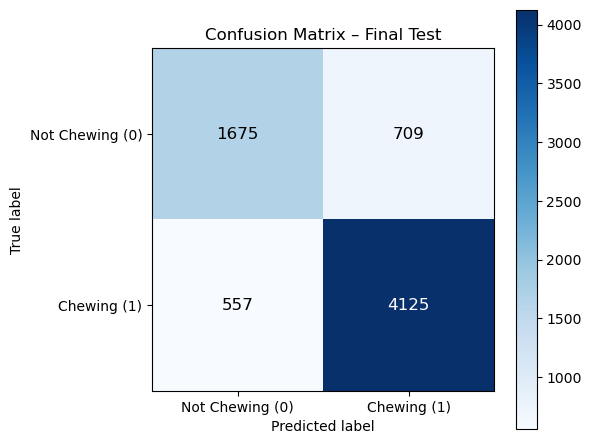

In [68]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix – Final Test")

classes = ["Not Chewing (0)", "Chewing (1)"]
ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j],
                ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black",
                fontsize=12)

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()
